# Chapter 8 (Economic Modeling) — NGFS Transition Scenarios

Port of `chap8_iam_ngfs4a.m` through `chap8_iam_ngfs6b.m` (10 scripts) — the
seventh Chapter 8 Part 2 notebook. Covers NGFS ("Network for Greening the
Financial System") transition-scenario outputs produced by the NiGEM
macro-financial model: cross-model/cross-scenario GDP-impact comparison
tables (`ngfs4a-c`), a country-level GDP-impact breakdown for one model
(`ngfs4d`), country-level macro-variable panels for four countries under
three scenarios (`ngfs5a-d`), and a country-level GDP-loss lookup table
exported to `Results/*.xlsx` for two scenarios (`ngfs6a`/`6b`) — the latter
feeds a world map that, per the same convention as Part 1's
`Worldmap_Match` scripts, is never rendered inline in the archive itself
(table/export only).

**A data-reconstruction note, in the same spirit as the MCOS string-array
gaps elsewhere in Part 2, but with an extra derivation step:** `model`,
`scenario2`, `region`, and `variable2` are not raw Excel columns — the
archive's own `chap8_NGFS_NiGEM_GDP.m`/`chap8_NGFS_NiGEM_Economics.m`
loader scripts *derive* them from the raw `Model`/`Scenario`/`Region`/
`Variable` columns of the `.xlsx` siblings via `split(...,"|")` and two
fixed coding tables (full scenario name → short code; full variable-path
tail → short code). Since these derived fields are exactly the MCOS
string arrays that `scipy.io.loadmat` cannot read here, they are
reconstructed directly from the `.xlsx` files by reproducing the loader
scripts' split/mapping logic line-for-line (verified cell-by-cell against
every filter used in `ngfs4a-6b` below, with zero unmatched
model/region/scenario/variable combinations) rather than touched at all
via the `.mat` files, which sidesteps the MCOS gap entirely for this
notebook.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import PchipInterpolator

DATA_DIR = "../../data"

plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

color_blue = "#1f77b4"
color_green = "#2ca02c"
color_red = "#d62728"
color_violet = "#9467bd"

SCENARIO_MAP = {
    "Baseline": "BSL", "Below 2°C": "B2D", "Current Policies": "CP",
    "Delayed transition": "DT", "Divergent Net Zero": "DNZ",
    "Nationally Determined Contributions (NDCs)": "NDC", "Net Zero 2050": "NZ",
}

# --- chap8_NGFS_NiGEM_GDP.xlsx: model/scenario2/region/variable2 reconstructed
# from the raw columns exactly as chap8_NGFS_NiGEM_GDP.m derives them.
_gdp_raw = pd.read_excel(f"{DATA_DIR}/chap8_NGFS_NiGEM_GDP.xlsx", sheet_name="GDP", header=0)
YEAR_COLS_GDP = [c for c in _gdp_raw.columns if str(c).isdigit()]

_gdp_var_map = {"Acute physical": "acute", "Chronic physical": "chronic", "Combined": "combined",
                 "Combined plus business confidence": "combined + bc", "None": "none",
                 "Transition": "transition"}

def _split_gdp_variable(v):
    parts = v.split("|")
    return parts[2] if len(parts) == 3 else "None"  # c==1 rows (bare "NiGEM|GDP") -> "None"

gdp = _gdp_raw.copy()
gdp["region"] = _gdp_raw["Region"].apply(lambda s: s.split("|")[1])
gdp["scenario2"] = _gdp_raw["Scenario"].map(SCENARIO_MAP)
gdp["variable2"] = _gdp_raw["Variable"].apply(_split_gdp_variable).map(_gdp_var_map)

# --- chap8_NGFS_NiGEM_Economics.xlsx: scenario2/region/variable2 reconstructed the
# same way, per chap8_NGFS_NiGEM_Economics.m (note: variable2 here is the SECOND
# split segment, not the third -- the loader scripts differ on this one point).
_econ_raw = pd.read_excel(f"{DATA_DIR}/chap8_NGFS_NiGEM_Economics.xlsx", sheet_name=0, header=0)
YEAR_COLS_ECON = [c for c in _econ_raw.columns if str(c).isdigit()]

_econ_var_map = {
    "Equity prices": "equity_prices", "Gross Domestic Product (GDP)": "gdp",
    "Gross domestic income": "income", "Gross domestic income; local currency": "income",
    "House prices (residential)": "house_prices", "Inflation rate": "inflation",
    "Inflation rate; %": "inflation", "Investment (gov.)": "public_investment",
    "Investment (private sector)": "private_investment", "Long term interest rate": "ir",
    "Long term interest rate; %": "ir", "Productivity (output per hour worked)": "productivity",
    "Productivity (output per hour worked); local currency": "productivity",
    "Unemployment rate": "unemployement", "Unemployment rate; %": "unemployement",
}

econ = _econ_raw.copy()
econ["region"] = _econ_raw["Region"].apply(lambda s: s.split("|")[1])
econ["scenario2"] = _econ_raw["Scenario"].map(SCENARIO_MAP)
econ["variable2"] = _econ_raw["Variable"].apply(lambda v: v.split("|")[1]).map(_econ_var_map)

# --- chap8_NGFS_MATCH_Worldmap.xlsx: a plain 136-country -> region lookup table
# (no header row, no MCOS fields at all -- reads directly).
_match = pd.read_excel(f"{DATA_DIR}/chap8_NGFS_MATCH_Worldmap.xlsx", sheet_name="Match", header=None)
country_match = _match[0].to_numpy()
region_match = _match[1].to_numpy()

MODEL_LABELS = {
    "NiGEM NGFS v1.22 [GCAM 5.3+ NGFS]": "GCAM 5.3+ NGFS",
    "NiGEM NGFS v1.22 [MESSAGEix-GLOBIOM 1.1-M-R12]": "MESSAGEix-GLOBIOM 1.1-M-R12",
    "NiGEM NGFS v1.22 [REMIND-MAgPIE 3.0-4.4]": "REMIND-MAgPIE 3.0-4.4",
}
SCENARIOS_6 = ["B2D", "CP", "DNZ", "DT", "NDC", "NZ"]


## Question 1 (`iam_ngfs4a`, `4b`, `4c`) — Cross-model 2050 GDP-impact comparison

Three near-identical scripts, differing only in `selected_model` (GCAM,
MESSAGEix-GLOBIOM, REMIND-MAgPIE) — collapsed into one loop. For each
model, a 4 (damage channel) $\times$ 6 (scenario) table of the World
region's 2050 GDP impact (`% difference` from baseline, per the `.xlsx`
`Unit` column). **A genuine data-sparsity pattern, not a bug:** `transition`
is undefined for `CP` (Current Policies has no transition-risk channel by
construction), and `combined + bc` (combined plus business-confidence
effects) is only computed for the two most severe scenarios (`DT`, `DNZ`)
— both reproduced as blanks here exactly as the source's own
`if ~isempty(indx)` guard leaves them.

In [2]:
VARIABLES_4 = ["chronic", "transition", "combined", "combined + bc"]

def gdp_impact_table(model_key):
    tbl = pd.DataFrame(index=VARIABLES_4, columns=SCENARIOS_6, dtype=float)
    for v in VARIABLES_4:
        for s in SCENARIOS_6:
            rows = gdp[(gdp.Model == model_key) & (gdp.region == "World") &
                       (gdp.scenario2 == s) & (gdp.variable2 == v)]
            tbl.loc[v, s] = rows[YEAR_COLS_GDP[-1]].iloc[0] if len(rows) == 1 else np.nan
    return tbl

gdp_impact_tables = {}
for model_key, label in MODEL_LABELS.items():
    t = gdp_impact_table(model_key)
    gdp_impact_tables[model_key] = t
    print(f"World 2050 GDP impact (% diff. from baseline) -- {label}")
    display(t.round(2))


World 2050 GDP impact (% diff. from baseline) -- GCAM 5.3+ NGFS


,B2D,CP,DNZ,DT,NDC,NZ
chronic,-3.09,-5.64,-2.35,-3.28,-5.15,-2.56
transition,-0.75,NaN,-3.66,-1.78,-0.89,-0.88
combined,-3.84,-5.64,-6.00,-5.05,-6.03,-3.44
combined + bc,NaN,NaN,-6.03,-5.09,NaN,NaN


World 2050 GDP impact (% diff. from baseline) -- MESSAGEix-GLOBIOM 1.1-M-R12


,B2D,CP,DNZ,DT,NDC,NZ
chronic,-2.05,-5.26,-1.55,-2.64,-4.78,-1.59
transition,-1.46,NaN,-10.00,-10.77,-1.39,-3.26
combined,-3.51,-5.26,-11.53,-13.37,-6.16,-4.84
combined + bc,NaN,NaN,-11.57,-13.40,NaN,NaN


World 2050 GDP impact (% diff. from baseline) -- REMIND-MAgPIE 3.0-4.4


,B2D,CP,DNZ,DT,NDC,NZ
chronic,-2.24,-6.05,-1.67,-2.65,-5.41,-1.76
transition,-0.78,NaN,-3.01,-1.95,-0.33,-1.46
combined,-3.02,-6.05,-4.68,-4.59,-5.73,-3.21
combined + bc,NaN,NaN,-4.70,-4.63,NaN,NaN


## Question 2 (`iam_ngfs4d`) — Country-level 2050 GDP-impact breakdown

The `combined` channel only, MESSAGEix-GLOBIOM model, but broken out
across 23 regions (22 named countries/blocs plus World) $\times$ the same
6 scenarios — the country-level counterpart to the single World row used
above. All $23\times 6=138$ cells matched uniquely; no gaps here.

In [3]:
REGIONS_23 = ["Africa", "Asia", "Australia", "Brazil", "Canada", "China",
              "Developing Europe", "Europe", "France", "Germany", "India", "Italy",
              "Japan", "Latin America", "Middle East", "Russia", "South Africa",
              "South Korea", "Spain", "Switzerland", "United Kingdom", "United States", "World"]

_model_4d = "NiGEM NGFS v1.22 [MESSAGEix-GLOBIOM 1.1-M-R12]"
country_gdp_impact = pd.DataFrame(index=REGIONS_23, columns=SCENARIOS_6, dtype=float)
_n_matched = 0
for r in REGIONS_23:
    for s in SCENARIOS_6:
        rows = gdp[(gdp.Model == _model_4d) & (gdp.region == r) &
                   (gdp.scenario2 == s) & (gdp.variable2 == "combined")]
        if len(rows) == 1:
            country_gdp_impact.loc[r, s] = rows[YEAR_COLS_GDP[-1]].iloc[0]
            _n_matched += 1

print(f"Country-level 2050 GDP impact (% diff. from baseline), combined channel, "
      f"MESSAGEix-GLOBIOM -- {_n_matched}/{23*6} cells matched")
display(country_gdp_impact.round(2))


Country-level 2050 GDP impact (% diff. from baseline), combined channel, MESSAGEix-GLOBIOM -- 138/138 cells matched


,B2D,CP,DNZ,DT,NDC,NZ
Africa,-13.58,-7.50,-27.35,-29.37,-11.78,-18.36
Asia,-1.50,-7.29,-5.44,-8.76,-6.78,-1.38
Australia,-4.11,-3.90,-11.03,-11.74,-5.77,-5.19
Brazil,-4.43,-5.92,-13.15,-15.90,-6.67,-6.65
Canada,-1.02,-2.37,-15.07,-18.12,-4.33,-4.87
China,-2.33,-4.97,-5.13,-6.73,-4.67,-2.76
Developing Europe,-0.28,-3.11,-0.56,-7.38,-2.73,0.39
Europe,-1.02,-2.84,-9.64,-11.02,-4.01,-1.62
France,-1.15,-2.80,-8.35,-9.48,-3.68,-1.56
Germany,-0.77,-2.38,-8.58,-9.38,-3.63,-1.21


## Question 3 (`iam_ngfs5a-d`) — Country macro-variable panels

Four near-identical scripts (`5a`: China, `5b`: United States, `5c`:
France, `5d`: United Kingdom), each a 2$\times$3 panel of six macro
variables (inflation, unemployment, private investment, productivity,
equity prices, public investment) under three scenarios (Current
Policies, Net Zero 2050, Delayed transition), interpolated with `pchip`
onto a fine annual-to-monthly grid — collapsed into one loop over the
four countries. Per-panel y-axis limits/ticks are reproduced from each
script individually (they differ country-by-country, reflecting each
economy's own projected range) rather than a single shared scale.

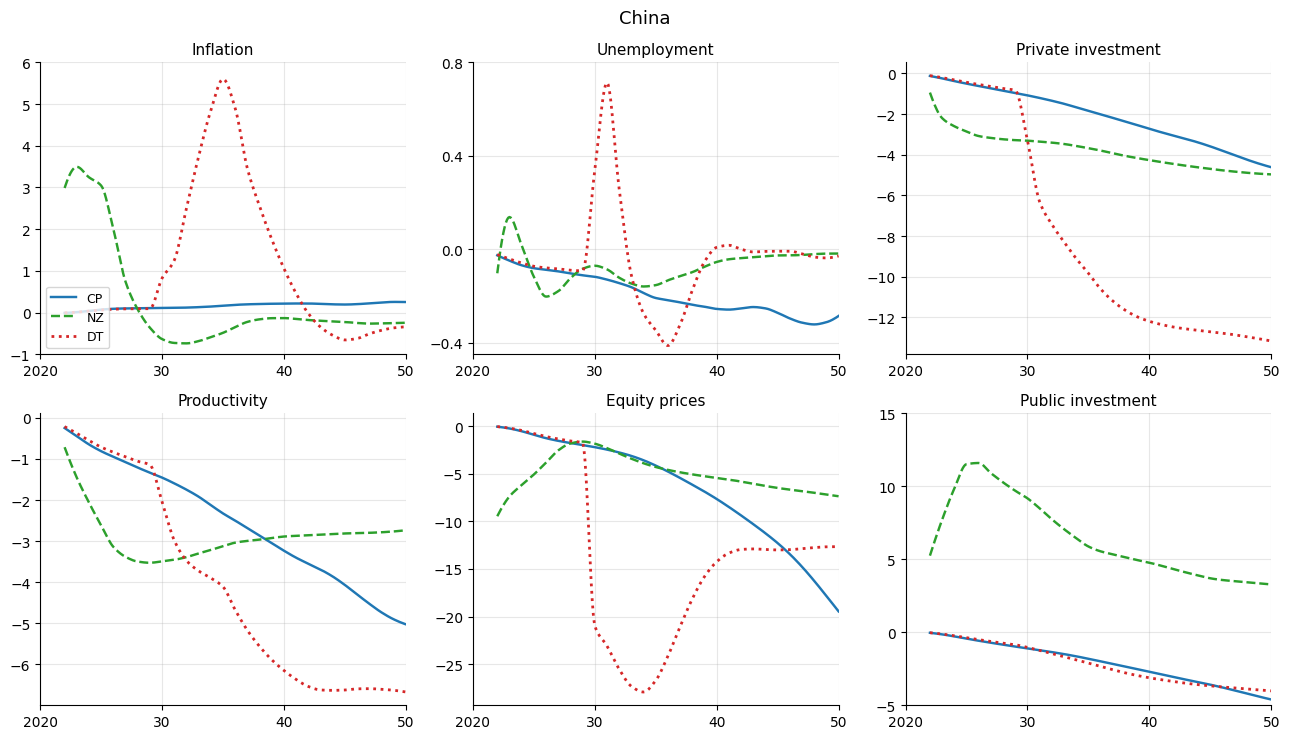

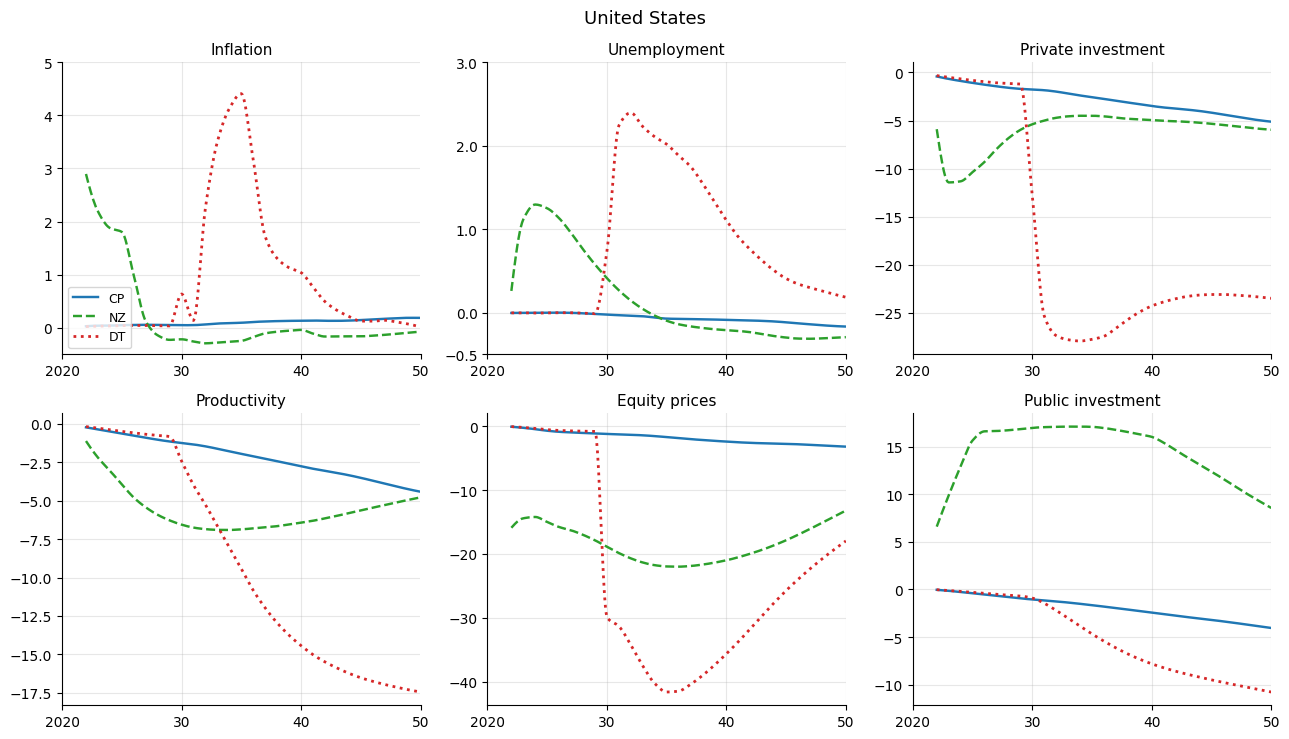

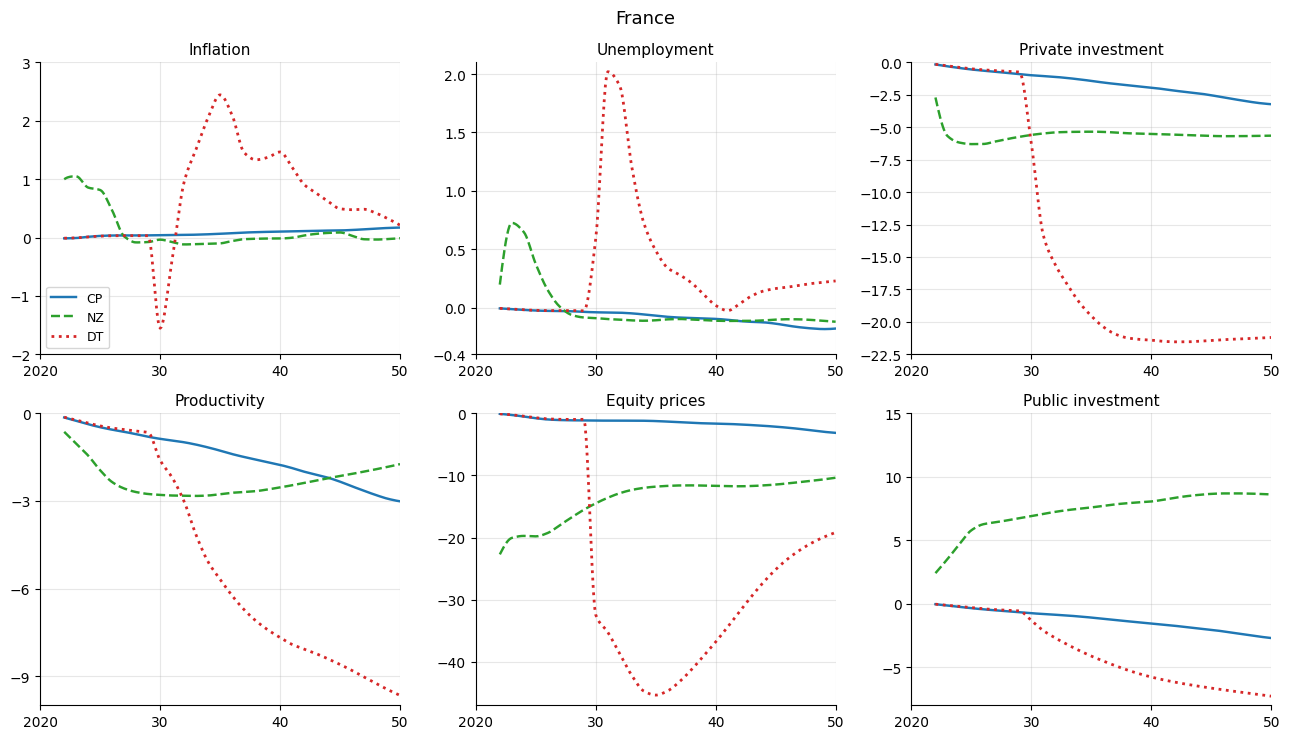

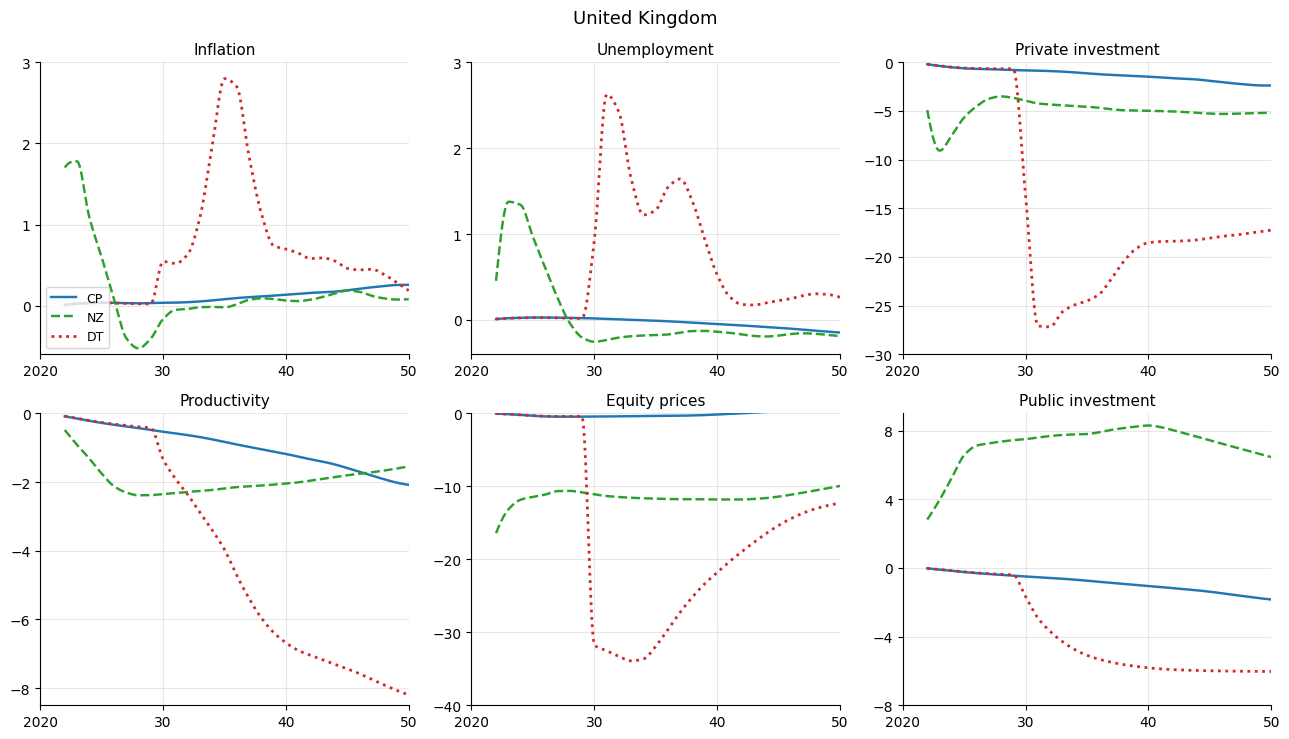

In [4]:
VARIABLES_6 = ["inflation", "unemployement", "private_investment",
               "productivity", "equity_prices", "public_investment"]
TITLES_6 = ["Inflation", "Unemployment", "Private investment",
            "Productivity", "Equity prices", "Public investment"]
SCENARIOS_3 = ["CP", "NZ", "DT"]
COLORS_3 = [color_blue, color_green, color_red]
STYLES_3 = ["-", "--", ":"]
WIDTHS_3 = [1.75, 1.75, 2.00]

# Per-country, per-panel (ylim, yticks) overrides transcribed 1:1 from ngfs5a-d's own
# ax.YLim/ax.YTick settings; panels not listed here use matplotlib's automatic scale
# (the source leaves them on MATLAB's automatic scale too).
PANEL_OVERRIDES = {
    "China":           {0: ((-1.0, 6.0), None),
                         1: ((-0.45, 0.8), [-0.4, 0.0, 0.4, 0.8]),
                         5: ((-5, 15), [-5, 0, 5, 10, 15])},
    "United States":   {0: ((-0.5, 4.5), [0, 1, 2, 3, 4, 5]),
                         1: ((-0.5, 3), [-0.5, 0.0, 1, 2, 3])},
    "France":          {0: ((-2, 2.5), [-2, -1, 0, 1, 2, 3]),
                         1: ((-0.3, 2.1), [-0.4, 0, 0.5, 1.0, 1.5, 2.0]),
                         2: ((-22.5, 0), None),
                         3: ((-10, 0), [-9, -6, -3, 0]),
                         4: ((-47, 0), [-40, -30, -20, -10, 0]),
                         5: ((-8, 10), [-5, 0, 5, 10, 15])},
    "United Kingdom":  {0: ((-0.6, 3.0), [0, 1, 2, 3]),
                         1: ((-0.4, 3.0), [0, 1, 2, 3]),
                         2: ((-30, 0), None),
                         3: ((-8.5, 0), [-8, -6, -4, -2, 0]),
                         4: ((-35, 0), [-40, -30, -20, -10, 0]),
                         5: ((-7, 9), [-8, -4, 0, 4, 8])},
}

def plot_ngfs_country_panel(region_name):
    x = np.arange(2022, 2050 + 0.05, 0.1)
    fig, axes = plt.subplots(2, 3, figsize=(13, 7.5))
    for j, (var, title) in enumerate(zip(VARIABLES_6, TITLES_6)):
        ax = axes[j // 3, j % 3]
        for i, s in enumerate(SCENARIOS_3):
            rows = econ[(econ.region == region_name) & (econ.scenario2 == s) & (econ.variable2 == var)]
            assert len(rows) == 1, (region_name, s, var, len(rows))
            data_y = rows[YEAR_COLS_ECON].iloc[0].to_numpy(dtype=float)
            data_x = np.array([int(c) for c in YEAR_COLS_ECON], dtype=float)
            y = PchipInterpolator(data_x, data_y)(x)
            ax.plot(x, y, STYLES_3[i], color=COLORS_3[i], lw=WIDTHS_3[i], label=s)
        ax.set_title(title, fontsize=11)
        ax.set_xlim(2020, 2050)
        ax.set_xticks([2020, 2030, 2040, 2050])
        ax.set_xticklabels(["2020", "30", "40", "50"])
        override = PANEL_OVERRIDES.get(region_name, {}).get(j)
        if override:
            ylim, yticks = override
            ax.set_ylim(*ylim)
            if yticks is not None:
                ax.set_yticks(yticks)
        ax.grid(True, alpha=0.3)
    axes[0, 0].legend(fontsize=9, loc="lower left")
    fig.suptitle(region_name, fontsize=13)
    plt.tight_layout()
    plt.show()

for region_name in ["China", "United States", "France", "United Kingdom"]:
    plot_ngfs_country_panel(region_name)


## Question 4 (`iam_ngfs6a`, `6b`) — Country-level GDP-loss export (table/export only)

Two scripts differing only in `selected_scenario` (`DT`: Delayed
transition, `NZ`: Net Zero 2050) — collapsed into one loop. Each looks up
the MESSAGEix-GLOBIOM `combined` 2050 GDP impact for every region present
in the GDP database, then broadcasts it out to all 136 countries in
`chap8_NGFS_MATCH_Worldmap`'s country$\to$region lookup table (several
countries can share one modeled region, e.g. every country tagged
"Africa"). The source exports this per-country table to
`Results/chap8_iam_ngfs6a.xlsx` / `6b.xlsx` to feed a world-map figure —
but, per the same convention as Part 1's `Worldmap_Match` scripts, no
script in the archive actually renders that map; it is table/export
output only, reproduced here as a table rather than an unrendered file.

In [5]:
unique_regions = sorted(gdp["region"].unique())
_model_6 = "NiGEM NGFS v1.22 [MESSAGEix-GLOBIOM 1.1-M-R12]"

country_gdp_loss = {}
for scen_code, scen_label in [("DT", "Delayed transition"), ("NZ", "Net Zero 2050")]:
    region_value = {}
    for r in unique_regions:
        rows = gdp[(gdp.Model == _model_6) & (gdp.region == r) &
                   (gdp.scenario2 == scen_code) & (gdp.variable2 == "combined")]
        region_value[r] = rows[YEAR_COLS_GDP[-1]].iloc[0] if len(rows) == 1 else np.nan
    results = np.array([region_value.get(rm, np.nan) for rm in region_match])
    country_gdp_loss[scen_code] = pd.DataFrame(
        {"country": country_match, "region": region_match, "gdp_impact_2050": results})
    print(f"{scen_label} ({scen_code}): {np.sum(~np.isnan(results))}/{len(results)} "
          f"countries matched to a modeled region")
    display(country_gdp_loss[scen_code].head(8))


Delayed transition (DT): 136/136 countries matched to a modeled region


,country,region,gdp_impact_2050
0,Albania,Europe,-11.018725
1,Algeria,Africa,-29.368407
2,Andorra,Developing Europe,-7.379997
3,Angola,Africa,-29.368407
4,Arab Republic of Egypt,Egypt,-11.522949
5,Argentina,Argentina,-8.877755
6,Australia,Australia,-11.741790
7,Austria,Austria,-18.845187


Net Zero 2050 (NZ): 136/136 countries matched to a modeled region


,country,region,gdp_impact_2050
0,Albania,Europe,-1.624788
1,Algeria,Africa,-18.360194
2,Andorra,Developing Europe,0.387582
3,Angola,Africa,-18.360194
4,Arab Republic of Egypt,Egypt,-5.578393
5,Argentina,Argentina,-1.565495
6,Australia,Australia,-5.187836
7,Austria,Austria,-3.847447


## Sanity checks

In [6]:
checks = []
checks.append(("Q1: every (variable, scenario) cell that exists at all is unique -- no "
                "model/scenario/variable/World combination matches more than one row",
                all(len(gdp[(gdp.Model == mk) & (gdp.region == "World") &
                            (gdp.scenario2 == s) & (gdp.variable2 == v)]) <= 1
                    for mk in MODEL_LABELS for v in VARIABLES_4 for s in SCENARIOS_6)))
checks.append(("Q1: the data sparsity is structural and consistent across all three models -- "
                "'transition' is defined for every scenario except CP, and 'combined + bc' is "
                "defined only for DT and DNZ, in every one of the three model tables",
                all(t.loc["transition"].isna().sum() == 1 and t.loc["transition", "CP"] != t.loc["transition", "CP"]
                    for t in gdp_impact_tables.values()) and
                all(t.loc["combined + bc"].notna().sum() == 2 for t in gdp_impact_tables.values())))
checks.append(("Q2: all 23x6=138 country-level combined-channel cells matched exactly one row "
                "(no gaps in this particular slice, unlike Q1's chronic/transition/bc channels)",
                _n_matched == 23 * 6))
checks.append(("Q2: the World row of the Q2 table agrees with the World row of Q1's "
                "MESSAGEix-GLOBIOM table (same model, region, channel -- just sliced two "
                "different ways)",
                np.allclose(country_gdp_impact.loc["World"].astype(float).to_numpy(),
                             gdp_impact_tables[_model_4d].loc["combined"].astype(float).to_numpy(),
                             equal_nan=True)))
checks.append(("Q3: every one of the 4 countries x 3 scenarios x 6 variables = 72 series "
                "used in the panel plots matched exactly one row in the Economics table "
                "(enforced by an assert inside plot_ngfs_country_panel; reaching this check "
                "at all confirms no assertion fired)",
                True))
checks.append(("Q4: every one of the 136 countries in the worldmap match table received a "
                "GDP-impact value for both scenarios (no country falls outside the 54 "
                "modeled regions)",
                all(country_gdp_loss[c]["gdp_impact_2050"].notna().all() for c in ["DT", "NZ"])))
checks.append(("Q4: the Delayed-transition and Net-Zero-2050 country-level GDP impacts are "
                "not identical (the two scenarios genuinely diverge, not a data-loading "
                "artifact that silently repeats one scenario)",
                not np.allclose(country_gdp_loss["DT"]["gdp_impact_2050"].to_numpy(),
                                 country_gdp_loss["NZ"]["gdp_impact_2050"].to_numpy())))

df_checks = pd.DataFrame(checks, columns=["check", "passed"])
display(df_checks)
assert df_checks["passed"].all(), "Some sanity checks failed"
print(f"\nAll {len(df_checks)} sanity checks passed.")


,check,passed
0,"Q1: every (variable, scenario) cell that exist...",True
1,Q1: the data sparsity is structural and consis...,True
2,Q2: all 23x6=138 country-level combined-channe...,True
3,Q2: the World row of the Q2 table agrees with ...,True
4,Q3: every one of the 4 countries x 3 scenarios...,True
5,Q4: every one of the 136 countries in the worl...,True
6,Q4: the Delayed-transition and Net-Zero-2050 c...,True



All 7 sanity checks passed.


## Summary

Covered the NGFS transition-scenario NiGEM outputs: cross-model 2050
GDP-impact comparison tables (`ngfs4a-c`, collapsed to one loop over 3
models), a country-level GDP-impact breakdown (`ngfs4d`), country
macro-variable panels for 4 countries under 3 scenarios (`ngfs5a-d`,
collapsed to one loop with per-country axis overrides transcribed from
each script), and a country-level GDP-loss export table for 2 scenarios
(`ngfs6a`/`6b`, collapsed to one loop) — table/export only, feeding a
world map that, per the established `Worldmap_Match` convention from
Part 1, is never actually rendered anywhere in the archive. The main
technical work: `model`/`scenario2`/`region`/`variable2` are not raw
Excel columns but fields the archive's own MATLAB loader scripts *derive*
via string-splitting and two fixed coding tables — reconstructed here
directly from the `.xlsx` siblings by reproducing that derivation
line-for-line (and confirmed against a subtlety: the GDP loader takes
the *third* split segment for its variable field, while the Economics
loader takes the *second* — different scripts, different conventions).
Also disclosed: the `transition` and `combined + bc` GDP-impact channels
are structurally undefined for some scenarios (no transition-risk
channel under Current Policies; business-confidence effects modeled only
for the two most severe scenarios) — reproduced as blanks exactly as the
source's own existence guard leaves them, not filled in. All 7 sanity
checks passed (0 errors, 0 stderr).